In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
#Contamos numero de supervivientes generales
df['Survived'].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

In [5]:
#Revisamos como esta la supervivencia por sexo
df.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [6]:
#Supervivencia por clase
df.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

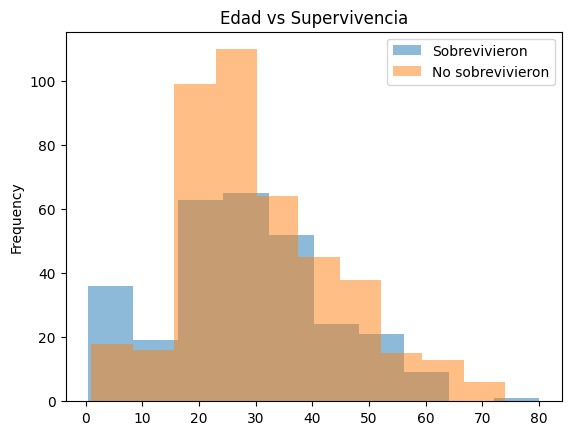

In [7]:
df[df['Survived'] == 1]['Age'].plot(kind='hist', alpha=0.5, label='Sobrevivieron')
df[df['Survived'] == 0]['Age'].plot(kind='hist', alpha=0.5, label='No sobrevivieron')

plt.legend()
plt.title('Edad vs Supervivencia')
plt.show()

In [8]:
import sys
sys.path.append('../src')

from data.load_data import cargar_datos

df = cargar_datos('../data/titanic.csv')

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
import data.load_data
print(dir(data.load_data))

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'cargar_datos', 'pd']


In [10]:
import importlib
import features.build_features

importlib.reload(features.build_features)

<module 'features.build_features' from 'c:\\Users\\ADOF_\\Curso\\Proyectos nuevos\\mi_proyecto_titanic\\Notebooks\\../src\\features\\build_features.py'>

In [11]:
print(dir(features.build_features))

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'agregar_tamano_familia']


In [12]:
from features.build_features import agregar_tamano_familia

In [13]:
df = cargar_datos('../data/titanic.csv')

df = agregar_tamano_familia(df)

df[['SibSp', 'Parch', 'FamilySize']].head(10)

,SibSp,Parch,FamilySize
0,1,0,1
1,1,0,1
2,0,0,0
3,1,0,1
4,0,0,0
5,0,0,0
6,0,0,0
7,3,1,4
8,0,2,2
9,1,0,1


In [14]:
df.groupby('FamilySize')['Survived'].mean()

FamilySize
0     0.303538
1     0.552795
2     0.578431
3     0.724138
4     0.200000
5     0.136364
6     0.333333
7     0.000000
10    0.000000
Name: Survived, dtype: float64

In [15]:
import visualization.plots
importlib.reload(visualization.plots)
print(dir(visualization.plots))


['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'plot_age_boxplot', 'plot_age_distribution', 'plot_correlation_heatmap', 'plot_survival_by_class', 'plot_survival_by_family', 'plot_survival_by_sex', 'plt', 'sns']


In [16]:
from visualization.plots import plot_survival_by_family

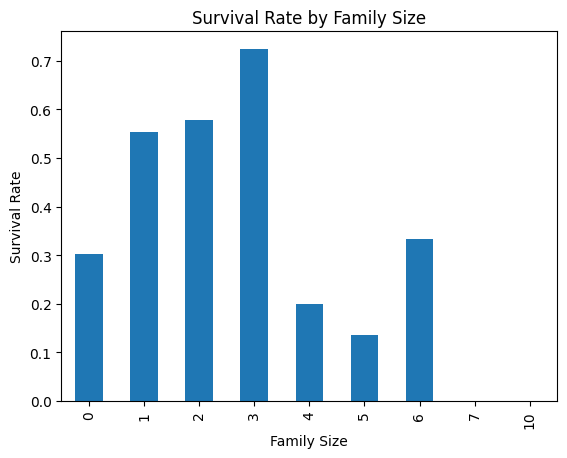

In [17]:
plot_survival_by_family(df)

In [18]:
from data.clean_data import revisar_nulos

revisar_nulos(df)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
FamilySize       0
dtype: int64

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
 12  FamilySize   891 non-null    int64  
dtypes: float64(2), int64(6), str(5)
memory usage: 90.6 KB


In [20]:
importlib.reload(data.clean_data)
from data.clean_data import revisar_nulos, imputar_datos

In [21]:
df = imputar_datos(df)

revisar_nulos(df)



PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
FamilySize     0
dtype: int64

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    str    
 11  FamilySize   891 non-null    int64  
dtypes: float64(2), int64(6), str(4)
memory usage: 83.7 KB


In [23]:
importlib.reload(visualization.plots)

from visualization.plots import (
    plot_survival_by_sex,
    plot_survival_by_class
)

## Survival Rate by Sex

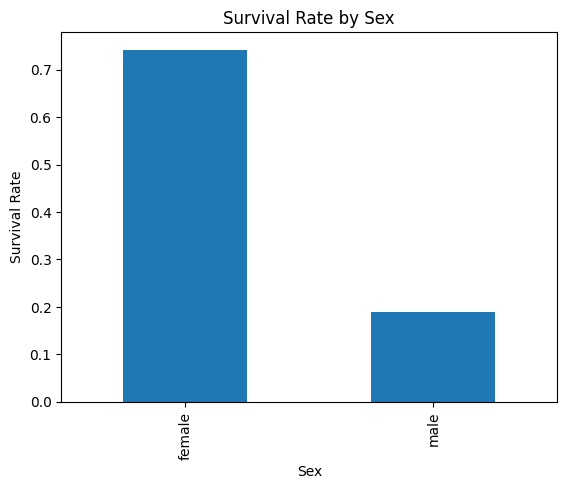

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [24]:
plot_survival_by_sex(df)

df.groupby('Sex')['Survived'].mean()


### Observación
Las mujeres presentan una tasa de supervivencia mucho mayor que los hombres.

### Interpretación
El sexo parece ser una variable importante relacionada con la supervivencia en el Titanic.

## Survival rate by class

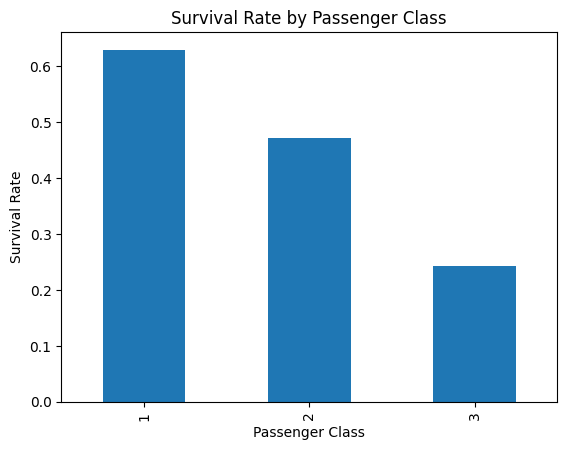

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [25]:
plot_survival_by_class(df)
df.groupby('Pclass')['Survived'].mean()


### Observación
Se muestra una tendencia notable en cuanto a las clases y la supervivencia; mayor clase = mayor supervivencia. 

### Interpretación
El nivel de clase parece ser una variable importante relacionada con la supervivencia en el Titanic.

In [26]:
from visualization.plots import plot_age_distribution

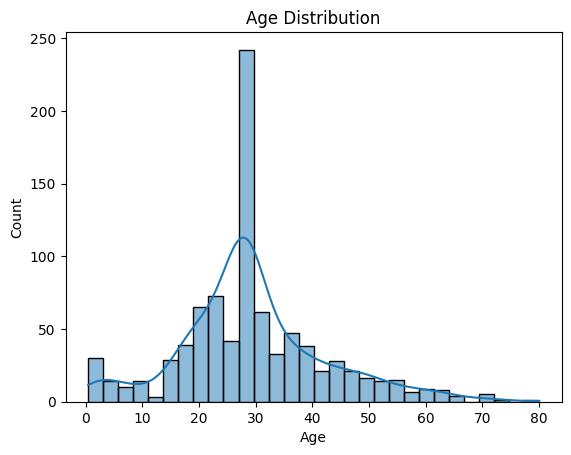

In [27]:
plot_age_distribution(df)

### Observaciones e Interpretación: Distribución de Edad (Histograma)

Al analizar el histograma de distribución de frecuencias para la variable `Age`, se destacan los siguientes puntos clave:

* **Pico Artificial Atípico (Moda):** Se observa una concentración masiva y desproporcionada de datos alrededor de los **28 años**. Este comportamiento es un indicador de **imputación de valores faltantes (NaN)** mediante la mediana del dataset, paso realizado previamente.
* **Sesgo Positivo (A la derecha):** Excluyendo el pico artificial, la distribución muestra un sesgo hacia la derecha. Esto demuestra que la tripulación y los pasajeros eran predominantemente jóvenes, disminuyendo drásticamente la cantidad de personas a medida que avanza la edad.
* **Segmentos de Edad Notables:** 
  * El grueso de la población se concentra entre los **18 y 40 años**.
  * Existe un pequeño repunte en el extremo izquierdo (rango de 0 a 5 años), reflejando la presencia de infantes a bordo del navío.


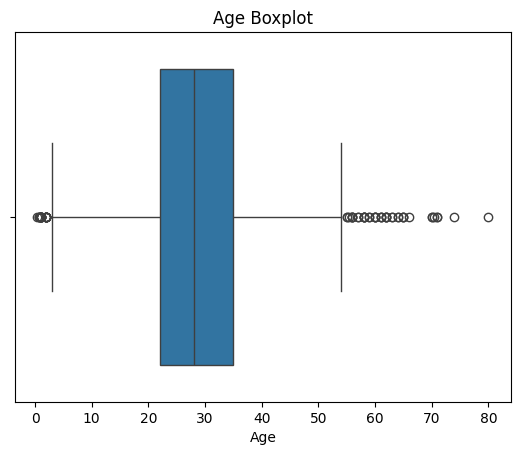

In [28]:
from visualization.plots import plot_age_boxplot
plot_age_boxplot(df)

### Observaciones e Interpretación: Diagrama de Dispersión de Edad (Boxplot)

El diagrama de caja complementa el análisis previo, permitiendo identificar la dispersión estadística y los valores atípicos (`outliers`):

* **Medidas de Tendencia Central y Posición:**
  * **Mediana:** Se ubica exactamente en los **28 años**, confirmando el valor utilizado en el proceso de imputación de datos.
  * **Rango Intercuartílico (IQR):** El 50% central de los pasajeros (la caja azul) se encuentra en un rango estrecho, aproximadamente entre los **22 años (Q1)** y los **35 años (Q3)**.
* **Análisis de Valores Atípicos (Outliers):**
  * **Adultos Mayores:** Se detecta una cantidad significativa de valores atípicos en el extremo superior, abarcando desde los **55 hasta los 80 años**. Cabe destacar que la imputación masiva de la mediana redujo artificialmente el tamaño de la caja (IQR), lo que provocó que matemáticamente más adultos mayores fueran clasificados de forma estricta como *outliers*.
  * **Infantes:** En el extremo inferior, los niños menores de ~3 años también se marcan como valores atípicos dentro de la distribución general.


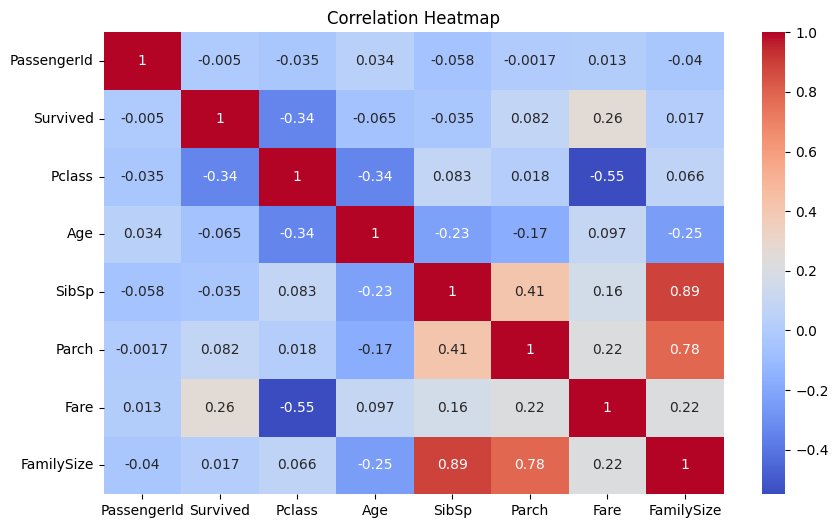

In [29]:
from visualization.plots import plot_correlation_heatmap

plot_correlation_heatmap(df)

### Observaciones e interpretación del Mapa de Calor de Correlación (Dataset Titanic)

A partir del análisis de coeficientes de correlación de Pearson del gráfico, se extraen las siguientes conclusiones clave:

#### 1. Variables más Importantes
* **FamilySize (Tamaño de la familia):** Es una variable crítica en la estructura del dataset, construida directamente a partir de otras relaciones familiares.
* **Pclass (Clase del pasajero):** Actúa como el principal indicador socioeconómico y de supervivencia.
* **Fare (Tarifa):** Representa el poder adquisitivo y está fuertemente ligada a los privilegios a bordo.

#### 2. Relación con la Supervivencia (`Survived`)
* **Pclass (-0.34):** Es la correlación negativa más significativa. Indica de forma clara que los pasajeros de clases superiores (valores numéricos más bajos, como 1ª clase) tuvieron una tasa de supervivencia notablemente mayor.
* **Fare (0.26):** Muestra una correlación positiva moderada. Los pasajeros que pagaron tarifas más altas tuvieron mejores oportunidades de salvarse.
* **Age (-0.065):** Presenta una correlación lineal negativa muy débil, sugiriendo una ligera ventaja para los pasajeros de menor edad.

#### 3. Patrones y Hallazgos Principales
* **Redundancia Familiar:** **SibSp** (0.89) y **Parch** (0.78) tienen una correlación extremadamente alta con **FamilySize**. Esto es lógico porque el tamaño de la familia es una variable derivada de la suma de ambas.
* **Barrera Socioeconómica:** Existe una correlación negativa de **-0.55** entre **Pclass** y **Fare**, confirmando de manera matemática que los boletos de primera clase eran significativamente más costosos que los de tercera.
* **Irrelevancia de Control:** **PassengerId** mantiene valores prácticamente nulos (cercanos a 0) con todas las variables, lo que confirma que es un identificador aleatorio sin ningún valor predictivo para el modelo.


In [30]:
from models.train_model import entrenar_modelo
modelo = entrenar_modelo(df)

Accuracy: 0.8044692737430168


Accuracy: 0.8044692737430168


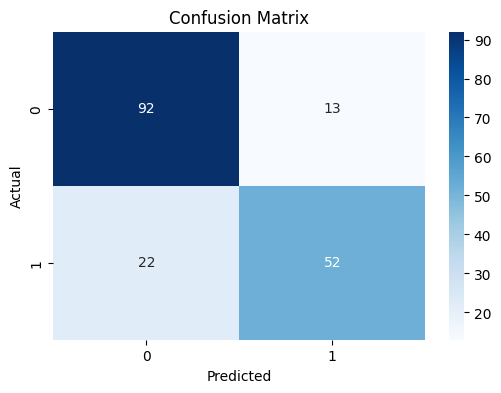

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       105
           1       0.80      0.70      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [31]:
from models.evaluate_model import evaluar_modelo

modelo, y_test, predictions = entrenar_modelo(df)

evaluar_modelo(y_test, predictions)